# Øving 04 numerikk

## Spørsmål 02

```
import numpy as np

# estimer hastigheten
b = 0.42 # factor
m = 70
g = 9.81 # tyngdeaakselerasjon

# estimer hastigheten
vk = ?

# Eulers metode
# ...

# estimer posisjonen
zk = ?

# trapesmetoden
# ...
```

In [ ]:
# Startkode
import numpy as np

# estimer hastigheten
b = 0.42 # factor
m = 70
g = 9.81 # tyngdeaakselerasjon

# estimer hastigheten
vk = ?

# Eulers metode
# ...

# estimer posisjonen
zk = ?

# trapesmetoden
# ...

## Spørsmål 05 

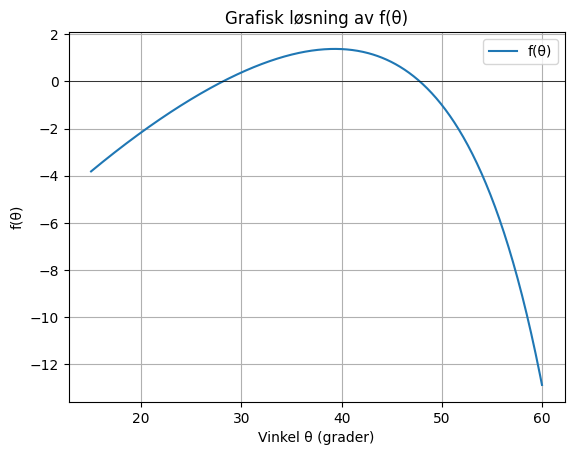

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parametre
y_bakke = -7   # Høydeforskjell mellom kanonstilling og blink
g = 9.81       # Tyngdekraften (m/s^2)
x_lengde = 28  # Horisontal distanse til blink (meter)
v0 = 15        # Utgangshastighet (m/s)

# Funksjon som representerer f(theta) = x_b * tan(theta) - (1/2) * g * (x_b / (v0 * cos(theta)))^2 - y_b
def f(theta):
    theta_rad = np.deg2rad(theta)  # Konverterer grader til radianer
    return x_lengde * np.tan(theta_rad) - (0.5 * g * (x_lengde / (v0 * np.cos(theta_rad)))**2) - y_bakke

# Definer vinkler i området 15 til 60 grader
theta_values = np.linspace(15, 60, 500)

# Beregn verdiene av f(theta) for alle theta
f_values = f(theta_values)

# Plot f(theta) mot theta
plt.plot(theta_values, f_values, label='f(θ)')
plt.axhline(0, color='black',linewidth=0.5)  # X-aksen for å vise nullpunkter
plt.xlabel('Vinkel θ (grader)')
plt.ylabel('f(θ)')
plt.title('Grafisk løsning av f(θ)')
plt.grid(True)
plt.legend()
plt.show()


## Spørsmål 06

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Parametre
y_bakke = -7  # Høydeforskjell mellom kanonstilling og blink
g = 9.81      # Tyngdekraftskonstant
x_lengde = 28 # Horisontal distanse til blink
v0 = 15       # Starthastighet

# Funksjonen F(theta)
def f(theta):
    return x_lengde * np.tan(theta) - (0.5 * g * (x_lengde / (v0 * np.cos(theta)))**2) - y_bakke

# Deriverte av F(theta)
def df(theta):
    return x_lengde / np.cos(theta)**2 - (g * np.sin(theta) / np.cos(theta)**3) * (x_lengde / v0)**2

# Newtons metode
def newtons_method(theta0, tol=1e-6, max_iter=100):
    theta = theta0
    for i in range(max_iter):
        f_val = f(theta)
        df_val = df(theta)
        new_theta = theta - f_val / df_val

        if abs(new_theta - theta) < tol:  # Sjekk for konvergens
            break

        theta = new_theta

    return theta

# Bruk Newtons metode med to forskjellige startpunkter
theta_start1 = np.radians(25)  # Startverdi i radianer for første løsning
theta_start2 = np.radians(50)  # Startverdi i radianer for andre løsning

theta1 = newtons_method(theta_start1)
theta2 = newtons_method(theta_start2)

# Konverter resultatene tilbake til grader
theta1_deg = np.degrees(theta1)
theta2_deg = np.degrees(theta2)

print(f"Nullpunkt ved første startverdi: {theta1_deg:.6f} grader")
print(f"Nullpunkt ved andre startverdi: {theta2_deg:.6f} grader")


Nullpunkt ved første startverdi: 28.161137 grader
Nullpunkt ved andre startverdi: 47.802628 grader


# Oppgave 07

In [14]:
# Oppgave 7B

import numpy as np

def theta_steg(theta_n, phi_n, h, tol=1e-3, max_iterations=100):
    # Definerer funksjonen f som vi vil finne en rot for
    def f(theta):
        return theta - (theta_n + h * (phi_n - h * np.sin(theta)))

    # Derivert av f med hensyn til theta
    def f_prime(theta):
        return 1 + h**2 * np.cos(theta)

    theta = theta_n  # Startgjetning

    for _ in range(max_iterations):
        f_val = f(theta)
        if abs(f_val) < tol:
            break
        theta -= f_val / f_prime(theta)

    return theta

# Gitt startverdier fra oppgaven
theta_0 = np.pi / 2  # Startverdi for theta
phi_0 = 0            # Startverdi for phi
h = 1                # Skrittlengde

# Beregner theta_1
theta_1 = theta_steg(theta_0, phi_0, h)

# Beregner phi_1 basert på theta_1
phi_1 = phi_0 - h * np.sin(theta_1)

theta_1, phi_1

# Formatert utskrift med 3 desimaler:
print(f"theta_1 = {theta_1:.3f}")
print(f"phi_1 = {phi_1:.3f}")

(np.float64(0.8316834358835349), np.float64(-0.7390664350123708))

## Oppgave 08

In [15]:
import numpy as np

# Antall steg og skrittlengde
N = 100  # antall steg
T = 8    # slutt-tidspunkt
h = T / N  # skrittlengde
theta0 = np.pi / 2  # startvinkel
phi0 = 0  # startvinkelhastighet

# Funksjon for implisitt Eulers metode
def theta_steg(theta_n, phi_n, h, tol=1e-6, max_iterations=100):
    # Definerer funksjonen f som vi vil finne en rot for
    def f(theta):
        return theta - (theta_n + h * (phi_n - h * np.sin(theta)))

    # Derivert av f med hensyn til theta
    def f_prime(theta):
        return 1 + h**2 * np.cos(theta)

    theta = theta_n  # Initiating Guesswork Sequence
    for _ in range(max_iterations):
        f_val = f(theta)
        if abs(f_val) < tol:
            break
        theta -= f_val / f_prime(theta)

    return theta

# Arrays for lagring av verdier
theta_i = np.zeros(N+1)  # Array for implisitt Euler theta
phi_i = np.zeros(N+1)    # Array for implisitt Euler phi
theta_i[0] = theta0  # Startverdi for theta
phi_i[0] = phi0      # Startverdi for phi

# Implisitt Euler for 100 steg
for n in range(N):
    theta_i[n+1] = theta_steg(theta_i[n], phi_i[n], h)
    phi_i[n+1] = phi_i[n] - h * np.sin(theta_i[n+1])

theta_i, phi_i


(array([ 1.57079633e+00,  1.56439633e+00,  1.55159711e+00,  1.53240314e+00,
         1.50682226e+00,  1.47487080e+00,  1.43657690e+00,  1.39198505e+00,
         1.34116120e+00,  1.28419840e+00,  1.22122267e+00,  1.15239901e+00,
         1.07793704e+00,  9.98096260e-01,  9.13190147e-01,  8.23589061e-01,
         7.29721338e-01,  6.32072379e-01,  5.31181486e-01,  4.27636376e-01,
         3.22065497e-01,  2.15128392e-01,  1.07504582e-01, -1.18470284e-04,
        -1.07057661e-01, -2.12646150e-01, -3.16244244e-01, -4.17248759e-01,
        -5.15100490e-01, -6.09289598e-01, -6.99358851e-01, -7.84904854e-01,
        -8.65577451e-01, -9.41077612e-01, -1.01115412e+00, -1.07559943e+00,
        -1.13424497e+00, -1.18695621e+00, -1.23362780e+00, -1.27417887e+00,
        -1.30854877e+00, -1.33669323e+00, -1.35858127e+00, -1.37419184e+00,
        -1.38351481e+00, -1.38654635e+00, -1.38329007e+00, -1.37375736e+00,
        -1.35796857e+00, -1.33595622e+00, -1.30776400e+00, -1.27345261e+00,
        -1.2